In [63]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv('Salary_dataset.csv')
df = df.drop(columns='Unnamed: 0')

In [64]:
display(df.head(5))
display(df.info())
display(df.describe())

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


None

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


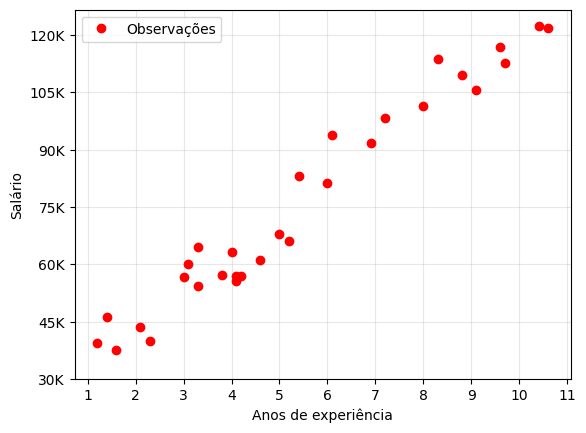

In [65]:
yticks = np.arange(30000,130000,15000)

yticks_formatado = []
for i in range(len(yticks)): yticks_formatado.append(str(f'{yticks[i]/1000:.0f}K'))

plt.figure()
plt.grid(alpha=0.3)
plt.plot(df['YearsExperience'],df['Salary'],'o',color='red',label='Observações')
plt.xticks(np.arange(1,12,1))
plt.xlabel('Anos de experiência')
plt.yticks(yticks,yticks_formatado)
plt.ylabel('Salário')
plt.legend()
plt.show()

[9449.96232146] [24848.20396652]


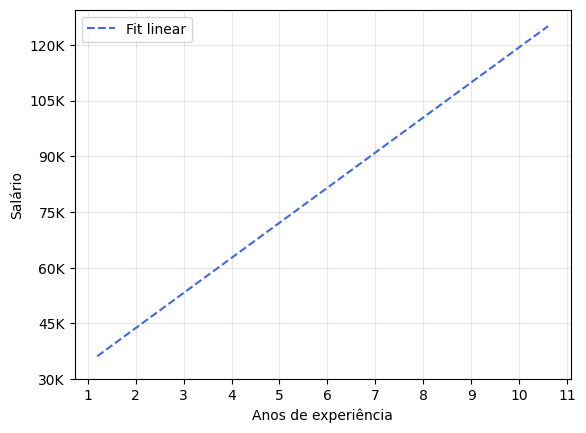

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           1.14e-20
Time:                        15:13:25   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.485e+04   2306.654     10.772      0.0

In [69]:
X = np.array(df['YearsExperience']).reshape(-1,1)
Y = np.array(df['Salary']).reshape(-1,1)

modelo = LinearRegression()
modelo.fit(X,Y)

Y_predict = modelo.predict(X)

inclinacao = modelo.coef_[0] 
intersecao = modelo.intercept_

print(inclinacao,intersecao)

plt.figure()
plt.grid(alpha=0.3)
plt.plot(X,Y_predict,ls='--',color='royalblue',label='Fit linear')
plt.xticks(np.arange(1,12,1))
plt.xlabel('Anos de experiência')
plt.yticks(yticks,yticks_formatado)
plt.ylabel('Salário')
plt.legend()
plt.show()

# 2. O GRANDE SEGREDO: Adicionar a constante (Intercepto)
# Ao contrário do Scikit-Learn, o statsmodels NÃO adiciona o w0 (intercepto) sozinho.
# Você precisa forçar a criação dessa coluna de 1s na sua matriz X.
X_com_constante = sm.add_constant(X)

# 3. Criando e treinando o modelo OLS (Ordinary Least Squares / Mínimos Quadrados)
# Note que a ordem dos argumentos é inversa ao Scikit-Learn: primeiro o y, depois o X
modelo_estatistico = sm.OLS(Y, X_com_constante).fit()

print(modelo_estatistico.summary())

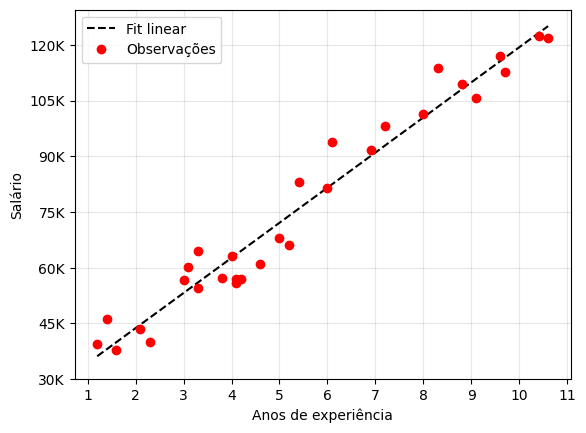

In [68]:
plt.figure()
plt.grid(alpha=0.3)
plt.plot(X,Y_predict,ls='--',color='black',label='Fit linear')
plt.plot(df['YearsExperience'],df['Salary'],'o',color='red',label='Observações')
plt.xticks(np.arange(1,12,1))
plt.xlabel('Anos de experiência')
plt.yticks(yticks,yticks_formatado)
plt.ylabel('Salário')
plt.legend()
plt.show()